<a href="https://colab.research.google.com/github/sebenemaryamashebir-cmd/cassava-disease-detector/blob/main/cassava_leaf_disease_cleaned.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



>



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
zip_path = "/content/drive/MyDrive/Cassava_Project/data.zip"

extract_path = "/content/cassava_dataset"

In [ ]:
import zipfile

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
import os

os.listdir(extract_path)

['Cassava___brown_streak_disease',
 'Cassava___bacterial_blight',
 'Cassava___healthy',
 'Cassava___green_mottle',
 'Cassava___mosaic_disease']

In [ ]:
import os

dataset_path = "/content/cassava_dataset"

for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):
        num_images = len(os.listdir(class_path))
        print(f"{class_name}: {num_images} images")


Cassava___brown_streak_disease: 2189 images
Cassava___bacterial_blight: 1087 images
Cassava___healthy: 2577 images
Cassava___green_mottle: 2386 images
Cassava___mosaic_disease: 13158 images


#**Data preparation**

## EDA
here it could be seen that my data is imbalanced. Cassava mosaic disease accounts for about 61% of all images whearas there is cassava bacteria blight disease that account for only about 5% of the images. this could cause accuracy problems during training and testing.Thus accurate processing strategy is needed for data. Thus we introduced augmentation methods like increasing variability for minority.



###Data Visualisation

In [ ]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

####leave inspection
taking radom leaves from each set of leaves to analtse.
aside from the healthy leave which could be easily distinguished , the bacteriablight sometimes look like brown streak and the green mottle sometimes look like the mosaic disease.this may cause some confusion during model classification(a hypothesis) we will find out if this hypothesis is true using the confusion matrix.

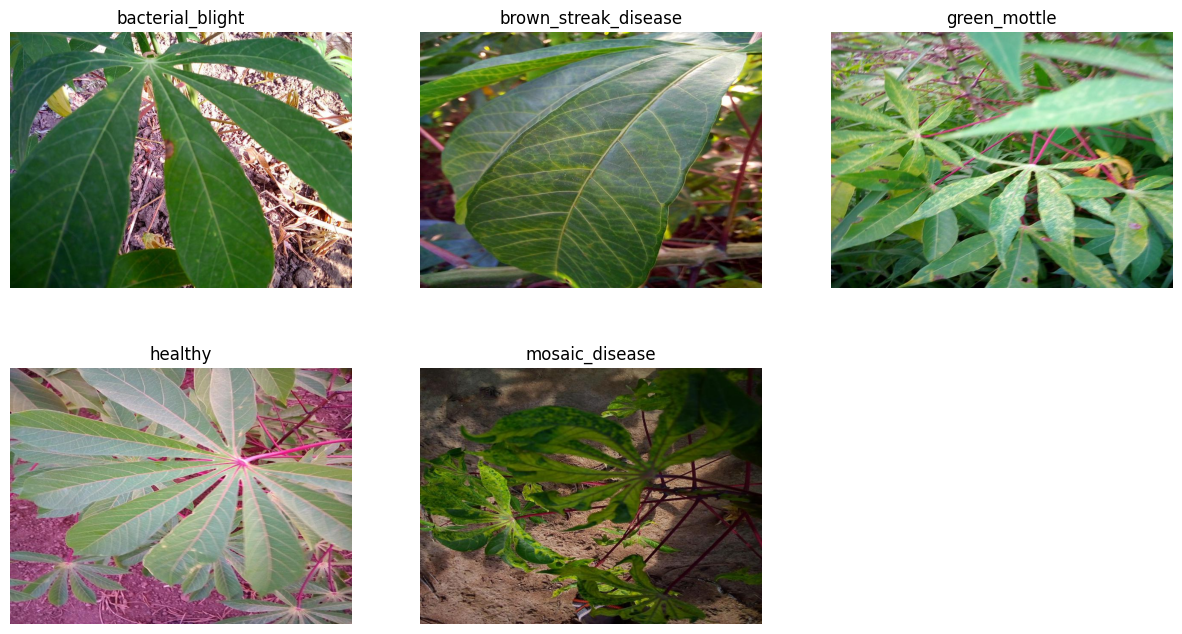

In [ ]:
dataset_path = "/content/cassava_dataset"

classes = sorted(os.listdir(dataset_path))

plt.figure(figsize=(15,8))

for i, class_name in enumerate(classes):

    class_folder = os.path.join(dataset_path, class_name)

    image_name = random.choice(os.listdir(class_folder))

    image_path = os.path.join(class_folder, image_name)

    img = Image.open(image_path)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(class_name.replace("Cassava___",""))
    plt.axis("off")

plt.show()

####image sizes
could be seen that images are of same size (800,600), so there would be no need for resizing into a single size.

In [ ]:
from PIL import Image
import os

dataset_path = "/content/cassava_dataset"

sizes = []

for class_name in os.listdir(dataset_path):

    class_folder = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_folder):

        for image_name in os.listdir(class_folder):

            image_path = os.path.join(class_folder,image_name)

            img = Image.open(image_path)

            sizes.append(img.size)

In [ ]:
unique_sizes = set(sizes)

print("Number of unique image sizes:", len(unique_sizes))

print(unique_sizes)

Number of unique image sizes: 1
{(800, 600)}


####corrupted images
here we checked if there are any corrupted images, like images that cannot be opened, since a corrupted image could cause an abrupt stop during training.we used img.verify instead of img.open because image.open only opens the file heade and doesnot give internal details but with img.verify it checks whether image file is complete and readable.

In [ ]:
from PIL import Image
import os

dataset_path = "/content/cassava_dataset"

corrupted_images = []

for class_name in os.listdir(dataset_path):

    class_folder = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_folder):

        for image_name in os.listdir(class_folder):

            image_path = os.path.join(class_folder, image_name)

            try:
                img = Image.open(image_path)
                img.verify()   # Verify image integrity

            except Exception:
                corrupted_images.append(image_path)

print("Number of corrupted images:", len(corrupted_images))

Number of corrupted images: 0


####class distribution
from the bar plot it could be seen that images for mozaic disease is dominant with bacteria blight disease having the least number of images.This might cause the model to be more accurate with classifying MD than the rest of the diseases.
we will fix this problem sing data augmentation, that is during training we will rotate, flipp, slightly zoom and make images from the minority classes slightly brighter. we will also use class weights, that is when definning our loss function, classes with fewer images will receive higher weights so that making a mistake with classes with fewer images would costly.

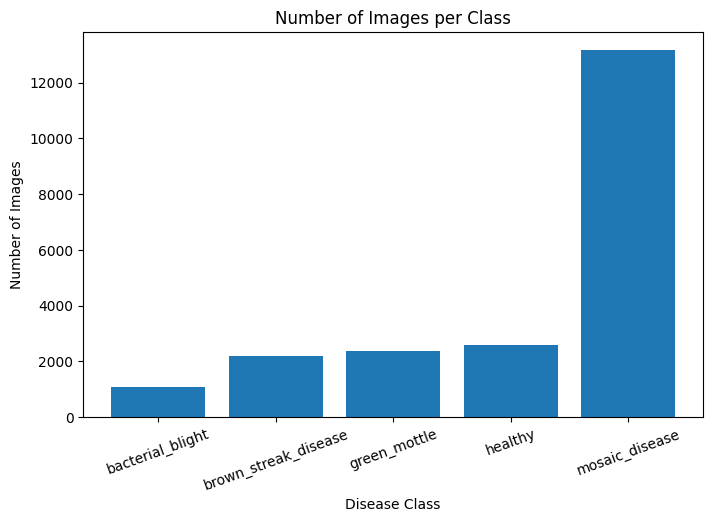

In [ ]:
import matplotlib.pyplot as plt
import os

dataset_path = "/content/cassava_dataset"

classes = []
counts = []

for class_name in sorted(os.listdir(dataset_path)):

    class_folder = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_folder):

        classes.append(class_name.replace("Cassava___", ""))
        counts.append(len(os.listdir(class_folder)))

plt.figure(figsize=(8,5))
plt.bar(classes, counts)

plt.title("Number of Images per Class")
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=20)

plt.show()